# State-Dependent Climate Alpha: A Walk-Forward Test of Green-Brown Industry Returns

**Research question.** Does the factor-neutral return differential between low- and high-emissions-intensity industries become predictable when climate-transition attention is unusually high, and does the sign or magnitude of that predictability depend on interest rates, oil prices, inflation, supply-chain conditions, and the business cycle?

This notebook is fully self-contained: given only the four CSV files in `data/`, it runs every exercise end to end -- data cleaning, factor-neutral spread construction, the attention signal and its macro purification, the original discrete-threshold trading strategies, statistical inference (Newey-West, block bootstrap, multiple-testing correction), a proposed improvement (a continuous conditioning signal) with its own out-of-sample validation, robustness checks, and a literature comparison. `reports/writeup.pdf` summarizes the results; every number in it is produced by this notebook.

In [1]:
from pathlib import Path
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
FIGURES = ROOT / "outputs" / "figures"
TABLES = ROOT / "outputs" / "tables"
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

@dataclass(frozen=True)
class Config:
    beta_window: int = 60
    macro_window: int = 120
    min_macro_obs: int = 60
    residual_vol_window: int = 36
    ridge: float = 0.10
    annual_vol_target: float = 0.05
    cost_asset: float = 10e-4
    cost_mkt: float = 5e-4
    cost_other_factor: float = 25e-4

CFG = Config()
FACTOR_COLS = ["Mkt-RF", "SMB", "HML"]
print("Setup complete.")


Setup complete.


## 1. Data and the Green/Brown industry legs

The five lowest- and five highest-emissions-intensity Fama-French industries form the Green and Brown legs. The emissions-intensity file covers 41 of the 49 FF industries; industries with no observation (including Oil) are excluded from the ranking -- a limitation of the underlying data, not a modeling choice.

In [2]:
emissions = pd.read_csv(DATA / "emissions_ff_industry.csv")
industries = pd.read_csv(DATA / "ff49_industry_monthly.csv", parse_dates=["date"]).set_index("date")
factors = pd.read_csv(DATA / "ff3_factors_monthly.csv", parse_dates=["date"]).set_index("date")
macro = pd.read_csv(DATA / "macro_monthly.csv", parse_dates=["date"]).set_index("date")

emissions.columns = emissions.columns.str.strip().str.lower()
emissions["ff"] = emissions["ff"].str.strip()
emissions["emissions_intensity"] = pd.to_numeric(emissions["emissions_intensity"])
ranked = emissions.sort_values("emissions_intensity")
LOW5 = ranked.head(5)["ff"].tolist()
HIGH5 = ranked.tail(5).sort_values("emissions_intensity", ascending=False)["ff"].tolist()
missing = sorted(set(industries.columns) - set(ranked["ff"]))
print("Green (low emissions):", LOW5)
print("Brown (high emissions):", HIGH5)
print("Industries with no emissions-intensity data (excluded from ranking):", missing)
print("Return sample:", industries.index.min().date(), "to", industries.index.max().date())

low_ret = industries[LOW5].mean(axis=1)
high_ret = industries[HIGH5].mean(axis=1)
green_brown = (low_ret - high_ret).rename("Green-Brown")
green_leg = (low_ret - factors["RF"]).rename("Green leg excess")
brown_leg = (high_ret - factors["RF"]).rename("Brown leg excess")


Green (low emissions): ['Fun', 'RlEst', 'Drugs', 'Telcm', 'Fin']
Brown (high emissions): ['Util', 'Ships', 'Aero', 'Steel', 'BldMt']
Industries with no emissions-intensity data (excluded from ranking): ['Chips', 'FabPr', 'Gold', 'Hshld', 'LabEq', 'Oil', 'Other', 'Toys']
Return sample: 1926-07-31 to 2026-07-31


## 2. Rolling FF3 factor neutralization

Betas and intercepts are estimated on a trailing 60-month window and shifted one month before use, so the hedge applied to month $t$ never uses information from month $t$ or later. This produces the factor-neutral innovation $\varepsilon_t$ that the trading signal attempts to predict.

In [3]:
def newey_west_regression(y, x, lags=6):
    data = pd.concat([y.rename("y"), x], axis=1).dropna()
    names = ["const"] + list(x.columns)
    X = np.column_stack([np.ones(len(data)), data[x.columns].to_numpy()])
    response = data["y"].to_numpy()
    inv = np.linalg.pinv(X.T @ X)
    coef = inv @ X.T @ response
    resid = response - X @ coef
    xu = X * resid[:, None]
    meat = xu.T @ xu
    for lag in range(1, min(lags, len(data) - 1) + 1):
        weight = 1.0 - lag / (lags + 1.0)
        gamma = xu[lag:].T @ xu[:-lag]
        meat += weight * (gamma + gamma.T)
    se = np.sqrt(np.clip(np.diag(inv @ meat @ inv), 0, None))
    return pd.DataFrame({"coef": coef, "t_hac6": coef / se}, index=names)

def rolling_factor_model(y, x, window=60):
    data = pd.concat([y.rename("y"), x], axis=1).dropna()
    betas = pd.DataFrame(index=data.index, columns=x.columns, dtype=float)
    intercept = pd.Series(index=data.index, dtype=float)
    for end in range(window - 1, len(data)):
        sample = data.iloc[end-window+1:end+1]
        X = np.column_stack([np.ones(window), sample[x.columns].to_numpy()])
        coef, *_ = np.linalg.lstsq(X, sample["y"].to_numpy(), rcond=None)
        intercept.iloc[end], betas.iloc[end] = coef[0], coef[1:]
    beta_used, alpha_used = betas.shift(1), intercept.shift(1)
    hedged = data["y"] - (beta_used * data[x.columns]).sum(axis=1, min_count=len(x.columns))
    epsilon = hedged - alpha_used
    return betas, hedged, epsilon

def factor_row(series, start, end):
    fit = newey_west_regression(series.loc[start:end], factors[FACTOR_COLS].loc[start:end])
    return {"alpha_ann": 12*fit.loc["const","coef"], "alpha_t": fit.loc["const","t_hac6"],
            "MKT": fit.loc["Mkt-RF","coef"], "SMB": fit.loc["SMB","coef"], "HML": fit.loc["HML","coef"]}

unconditional = pd.DataFrame({
    "Full 1970-Jul2022": factor_row(green_brown, "1970-01-31", "2022-07-31"),
    "Post-2010": factor_row(green_brown, "2010-01-31", "2022-07-31"),
}).T
print("Unconditional Green-Brown FF3 regression (raw, unhedged spread):")
display(unconditional)

asset_returns = {"Green-Brown": green_brown, "Green leg": green_leg, "Brown leg": brown_leg}
asset_models = {}
for name, series in asset_returns.items():
    aligned = pd.concat([series, factors[FACTOR_COLS]], axis=1).dropna()
    b, h, e = rolling_factor_model(aligned.iloc[:,0], aligned[FACTOR_COLS], CFG.beta_window)
    asset_models[name] = {"return": aligned.iloc[:,0], "betas": b, "hedged": h, "epsilon": e}
print("Rolling FF3 neutralization complete for Green-Brown, Green leg, and Brown leg.")


Unconditional Green-Brown FF3 regression (raw, unhedged spread):


,alpha_ann,alpha_t,MKT,SMB,HML
Full 1970-Jul2022,0.0089,0.6464,-0.0178,0.0062,-0.2380
Post-2010,-0.0055,-0.2192,-0.0463,-0.0445,-0.3505


Rolling FF3 neutralization complete for Green-Brown, Green leg, and Brown leg.


**Interpretation.** The unconditional alpha is small and statistically indistinguishable from zero in both windows, so a naive "always long Green, short Brown" position is not a reliable strategy on its own. The negative HML loading is the more informative number: Green industries (real estate, financials, pharma) skew toward growth/duration-sensitive business models, while Brown industries (utilities, steel, building materials) skew toward classic value stocks. This means part of any observed "climate" return is really compensation for a value-versus-growth tilt that has nothing to do with transition risk, and it is why the rest of this notebook works with the *factor-neutral residual* $\varepsilon_t$ rather than the raw spread -- any timing signal built on the raw spread would be partly (and misleadingly) a bet on growth stocks outperforming value stocks.

## 3. The attention signal, the extreme-state threshold, and macro purification

Extreme transition-risk attention is defined with an *expanding*, past-only 80th percentile of standardized attention -- a month only counts as extreme relative to history available strictly before it, so there is no look-ahead. Attention is also orthogonalized against rate, oil, inflation, and activity shocks using a 120-month walk-forward ridge regression, producing a 'purified' version of the same threshold rule.

In [4]:
def rolling_z(s, window=60, min_periods=36):
    return (s - s.rolling(window, min_periods=min_periods).mean()) / s.rolling(window, min_periods=min_periods).std(ddof=1).replace(0, np.nan)

attention = rolling_z(np.log1p(macro["attention"]))
rate_shock = rolling_z(macro["rate10y"].diff())
oil_return = rolling_z(np.log(macro["wti"]).diff())

def expanding_tail(series, q=.80, min_history=60):
    threshold = series.shift(1).expanding(min_periods=min_history).quantile(q)
    return series.gt(threshold) & threshold.notna()

original_p80 = expanding_tail(attention)
print("Original p80 months, 2010-Jul2026:", int(original_p80.loc["2010":"2026-07"].sum()))

inflation_yoy = 100*np.log(macro["cpi"]).diff(12)
safe_controls = pd.DataFrame({
    "rate_shock": rate_shock,
    "oil_return": oil_return,
    "inflation_level_l1": rolling_z(inflation_yoy.shift(1)),
    "inflation_accel_l1": rolling_z(inflation_yoy.diff().shift(1)),
    "activity_l1": rolling_z(macro["activity"].shift(1)),
})
extended_controls = safe_controls.copy()
extended_controls["recession"] = macro["recession"].astype(float)
extended_controls["supply_chain_l1"] = rolling_z(macro["supply_chain"].shift(1))

def ridge_predict(train_y, train_x, test_x, ridge=.10):
    X = np.column_stack([np.ones(len(train_x)), train_x.to_numpy(float)])
    penalty = np.eye(X.shape[1])*ridge; penalty[0,0] = 0
    coef = np.linalg.solve(X.T@X + penalty, X.T@train_y.to_numpy(float))
    return float(np.r_[1, test_x.to_numpy(float)] @ coef)

def rolling_oos_prediction(y, x, window=120, min_obs=60, ridge=.10):
    panel = x.join(y.rename("target"), how="outer").sort_index()
    pred = pd.Series(np.nan, index=panel.index)
    for date in panel.index:
        if panel.loc[date, x.columns].isna().any(): continue
        train = panel.loc[panel.index < date, [*x.columns,"target"]].dropna().tail(window)
        if len(train) >= min_obs:
            pred.loc[date] = ridge_predict(train.target, train[x.columns], panel.loc[date,x.columns], ridge=ridge)
    return pred

attention_prediction = rolling_oos_prediction(attention, safe_controls, window=CFG.macro_window, min_obs=CFG.min_macro_obs, ridge=CFG.ridge)
pure_attention = attention - attention_prediction
pure_p80 = expanding_tail(pure_attention)
print("Purified p80 months, 2010-Jul2026:", int(pure_p80.loc["2010":"2026-07"].sum()))


Original p80 months, 2010-Jul2026: 34


Purified p80 months, 2010-Jul2026: 37


### Signal-purity diagnostic

How much of attention's variation is explained by macro conditions, before vs. after purification (raw attention evaluated on the same walk-forward-restricted sample as the purified signal, for a fair comparison; an ex-post-only extended control set adding GSCPI/NBER recession is shown for context only, since those variables are not real-time usable).

,n,macro_r_squared
signal,,
Raw attention,390,6.2443
Purified attention (investable),390,0.8340
Raw attention vs. extended (ex-post) controls,310,12.2137


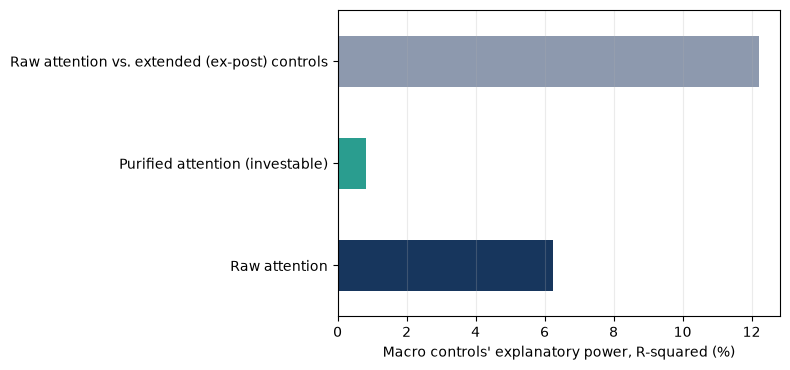

In [5]:
def macro_r_squared(signal, controls):
    data = pd.concat([signal.rename("y"), controls], axis=1).dropna()
    X = np.column_stack([np.ones(len(data)), data[controls.columns].to_numpy(float)])
    y = data["y"].to_numpy(float)
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ coef
    ss_res, ss_tot = (resid**2).sum(), ((y-y.mean())**2).sum()
    return (1 - ss_res/ss_tot if ss_tot>0 else np.nan), len(data)

common_idx = pure_attention.dropna().index
r2_raw, n_raw = macro_r_squared(attention.reindex(common_idx), safe_controls)
r2_pure, n_pure = macro_r_squared(pure_attention, safe_controls)
r2_ext, n_ext = macro_r_squared(attention, extended_controls)
diagnostics = pd.DataFrame([
    {"signal": "Raw attention", "n": n_raw, "macro_r_squared": r2_raw},
    {"signal": "Purified attention (investable)", "n": n_pure, "macro_r_squared": r2_pure},
    {"signal": "Raw attention vs. extended (ex-post) controls", "n": n_ext, "macro_r_squared": r2_ext},
]).set_index("signal")
display(diagnostics.assign(macro_r_squared=100*diagnostics.macro_r_squared))

fig, ax = plt.subplots(figsize=(8,3.8))
(100*diagnostics.macro_r_squared).plot.barh(ax=ax, color=["#17365D","#2A9D8F","#8D99AE"])
ax.set_xlabel("Macro controls' explanatory power, R-squared (%)"); ax.set_ylabel(""); ax.grid(axis="x", alpha=.25)
plt.tight_layout()
fig.savefig(FIGURES / "figure_1_signal_purity.pdf"); fig.savefig(FIGURES / "figure_1_signal_purity.png", dpi=150)
plt.show()


### Information Coefficient: does the signal actually predict returns?

Macro $R^2$ (above) measures how much of the *signal itself* is explained by macro conditions; it says nothing about whether the signal predicts returns. The standard measure for that is the **Information Coefficient (IC)**: the correlation between the signal at month $t$ and the Brown leg's factor-neutral return at month $t+1$ (the exact return the strategy is trying to time). We estimate it as the slope of a regression of the standardized forward return on the standardized signal, with Newey-West HAC standard errors -- numerically equivalent to a Pearson correlation, but with the same robust-inference treatment used everywhere else in this notebook. Because the strategy shorts Brown when attention is high, a **negative** IC is the economically "correct" sign: high attention should predict *lower* subsequent Brown returns.

In [6]:
def information_coefficient(signal, forward_series, start=None, end=None, lags=6):
    fwd = forward_series.shift(-1)
    data = pd.concat([signal.rename("x"), fwd.rename("y")], axis=1).dropna()
    if start: data = data.loc[start:]
    if end: data = data.loc[:end]
    if len(data) < 10: return np.nan, np.nan, len(data)
    zx = (data["x"] - data["x"].mean()) / data["x"].std(ddof=1)
    zy = (data["y"] - data["y"].mean()) / data["y"].std(ddof=1)
    fit = newey_west_regression(zy, zx.to_frame("signal_z"), lags=lags)
    return fit.loc["signal_z", "coef"], fit.loc["signal_z", "t_hac6"], len(data)

ic_windows = {"Full 2010-Jul2026": ("2010-01-31", "2026-07-31"),
              "Validation 2010-Jul2022": ("2010-01-31", "2022-07-31"),
              "Holdout Aug2022-Jul2026": ("2022-08-31", "2026-07-31")}
ic_rows = []
for sig_name, sig in [("Raw attention", attention), ("Purified attention", pure_attention)]:
    for label, (s, e) in ic_windows.items():
        ic, t, n = information_coefficient(sig, asset_models["Brown leg"]["epsilon"], s, e)
        ic_rows.append({"signal": sig_name, "period": label, "IC": ic, "t_hac6": t, "n": n})
ic_table = pd.DataFrame(ic_rows)
display(ic_table)


,signal,period,IC,t_hac6,n
0,Raw attention,Full 2010-Jul2026,-0.0288,-0.3940,198
1,Raw attention,Validation 2010-Jul2022,-0.0915,-1.2065,151
2,Raw attention,Holdout Aug2022-Jul2026,0.1234,1.1122,47
3,Purified attention,Full 2010-Jul2026,-0.0205,-0.3114,196
4,Purified attention,Validation 2010-Jul2022,-0.0773,-1.1576,151
5,Purified attention,Holdout Aug2022-Jul2026,0.1316,1.2220,45


**Interpretation.** In the validation period both signals carry the economically correct (negative) sign, though neither is strongly significant on its own (IC $\approx -0.08$ to $-0.09$, $t\approx-1.2$): high attention is weakly associated with lower subsequent Brown returns, as the short-Brown hypothesis requires. In the holdout, both signals **flip sign** to a positive IC of about $0.12$-$0.13$ ($t\approx1.1$-$1.2$) -- high attention is now associated with *higher*, not lower, subsequent Brown returns. This is an independent confirmation, at the level of the raw signal itself rather than the final strategy return, of the holdout failure documented in Section 4: it is not only that the trading rule lost money out of sample, but that the underlying predictive relationship it depends on inverted. Purification does not meaningfully change this picture -- whatever benefit it has is about removing macro contamination from the signal, not about strengthening or stabilizing its raw predictive correlation with next-month Brown returns.

## 4. Strategy construction: Short Brown after an extreme-attention crossing

A threshold crossing initiates a fixed 3- or 6-month Short-Brown window. Positions target 5% annualized residual volatility (36-month trailing), are capped at 1x notional, and the position formed at month-end $t$ earns month $t+1$'s return (no same-month execution look-ahead). Costs and a factor overlay (to keep the position factor-neutral) are charged explicitly.

In [7]:
def cross_and_holds(state):
    state = state.astype(bool)
    cross = state & ~state.shift(1).fillna(False).astype(bool)
    return cross, cross.rolling(3,min_periods=1).max().astype(bool), cross.rolling(6,min_periods=1).max().astype(bool)

def state_position(state, residual, direction, annual_vol_target=.05, vol_window=36):
    sigma = residual.rolling(vol_window, min_periods=vol_window).std(ddof=1)
    magnitude = (annual_vol_target/(np.sqrt(12)*sigma)).clip(upper=1.0)
    position = pd.Series(np.nan, index=residual.index)
    live = position.index >= sigma.first_valid_index()
    position.loc[live] = (direction*magnitude).loc[live].where(state.reindex(position.index).fillna(False),0)
    return position

def continuous_position(weight, residual, direction, annual_vol_target=.05, vol_window=36):
    sigma = residual.rolling(vol_window, min_periods=vol_window).std(ddof=1)
    magnitude = (annual_vol_target/(np.sqrt(12)*sigma)).clip(upper=1.0)
    position = pd.Series(np.nan, index=residual.index)
    live = position.index >= sigma.first_valid_index()
    w = weight.reindex(position.index).fillna(0).clip(lower=0.0, upper=1.0)
    position.loc[live] = (direction*magnitude*w).loc[live]
    return position

def asset_strategy_returns(position, model, leg_multiplier=1.0):
    idx = position.index.intersection(model["return"].index).intersection(factors.index).intersection(model["betas"].index)
    h = position.reindex(idx); idx = idx[idx >= h.first_valid_index()]; h = h.reindex(idx).fillna(0)
    beta = model["betas"].reindex(idx); f = factors[FACTOR_COLS].reindex(idx)
    overlay = pd.DataFrame(-h.to_numpy()[:,None]*beta.to_numpy(), index=idx, columns=beta.columns)
    gross = h.shift(1)*model["return"].reindex(idx) + (overlay.shift(1)*f).sum(axis=1,min_count=len(FACTOR_COLS))
    asset_turnover = leg_multiplier*h.diff().abs().fillna(h.abs())
    overlay_turnover = overlay.diff().abs().fillna(overlay.abs())
    cost = CFG.cost_asset*asset_turnover + CFG.cost_mkt*overlay_turnover["Mkt-RF"]
    cost += CFG.cost_other_factor*overlay_turnover[["SMB","HML"]].sum(axis=1)
    return pd.DataFrame({"position":h,"gross_return":gross,"net_return":gross-cost.shift(1).fillna(0),"turnover":asset_turnover+overlay_turnover.sum(axis=1)})

_, original_h3, original_h6 = cross_and_holds(original_p80)
_, pure_h3, pure_h6 = cross_and_holds(pure_p80)
baseline_models = {
    "Original | Short Brown hold 3m": asset_strategy_returns(state_position(original_h3, asset_models["Brown leg"]["epsilon"], -1), asset_models["Brown leg"]),
    "Pure | Short Brown hold 3m": asset_strategy_returns(state_position(pure_h3, asset_models["Brown leg"]["epsilon"], -1), asset_models["Brown leg"]),
    "Original | Short Brown hold 6m": asset_strategy_returns(state_position(original_h6, asset_models["Brown leg"]["epsilon"], -1), asset_models["Brown leg"]),
    "Pure | Short Brown hold 6m": asset_strategy_returns(state_position(pure_h6, asset_models["Brown leg"]["epsilon"], -1), asset_models["Brown leg"]),
}
print("Baseline strategies built:", list(baseline_models.keys()))


Baseline strategies built: ['Original | Short Brown hold 3m', 'Pure | Short Brown hold 3m', 'Original | Short Brown hold 6m', 'Pure | Short Brown hold 6m']


### Performance across periods

In [8]:
PERIODS = {
    "Full 2010-Jul2026": ("2010-01-31", "2026-07-31"),
    "Validation 2010-Jul2022": ("2010-01-31", "2022-07-31"),
    "Holdout Aug2022-Jul2026": ("2022-08-31", "2026-07-31"),
    "Pre-COVID 2010-2019": ("2010-01-31", "2019-12-31"),
    "COVID 2020-2021": ("2020-01-31", "2021-12-31"),
    "Inflation/rates 2022-2024": ("2022-01-31", "2024-12-31"),
    "Recent 12m (Aug2025-Jul2026)": ("2025-08-31", "2026-07-31"),
    "Recent 18m (Feb2025-Jul2026)": ("2025-02-28", "2026-07-31"),
}

def period_stats(net_return_series, start, end, label=None):
    s = net_return_series.loc[start:end].dropna()
    if len(s) == 0: return None
    active = s[s != 0]
    ann_net = 12*s.mean()
    ann_vol = np.sqrt(12)*s.std(ddof=1) if len(s)>1 else np.nan
    sharpe = ann_net/ann_vol if ann_vol else np.nan
    wealth = (1+s).cumprod()
    dd = (wealth/wealth.cummax()-1).min()
    fit = newey_west_regression(s, factors[FACTOR_COLS].loc[s.index])
    return {"period": label, "n_months": len(s), "active_months": len(active), "ann_net": ann_net, "ann_vol": ann_vol,
            "sharpe_net": sharpe, "max_drawdown": dd, "alpha_ann": 12*fit.loc["const","coef"], "alpha_t_hac6": fit.loc["const","t_hac6"],
            "MKT_beta": fit.loc["Mkt-RF","coef"], "SMB_beta": fit.loc["SMB","coef"], "HML_beta": fit.loc["HML","coef"],
            "SMB_t": fit.loc["SMB","t_hac6"], "HML_t": fit.loc["HML","t_hac6"]}

def all_period_stats(net_return_series):
    return pd.DataFrame([r for label,(s,e) in PERIODS.items() if (r:=period_stats(net_return_series, s, e, label)) is not None])

rows = []
for name, df in baseline_models.items():
    stats = all_period_stats(df["net_return"]); stats.insert(0, "strategy", name); rows.append(stats)
baseline_table = pd.concat(rows, ignore_index=True)
view = baseline_table[baseline_table.period.isin(["Validation 2010-Jul2022","Holdout Aug2022-Jul2026"])]
display(view[["period","strategy","ann_net","ann_vol","sharpe_net","alpha_ann","alpha_t_hac6","active_months","max_drawdown"]])


,period,strategy,ann_net,ann_vol,sharpe_net,alpha_ann,alpha_t_hac6,active_months,max_drawdown
1,Validation 2010-Jul2022,Original | Short Brown hold 3m,0.0131,0.0317,0.4124,0.0133,1.4683,74,-0.0761
2,Holdout Aug2022-Jul2026,Original | Short Brown hold 3m,-0.0382,0.0331,-1.1532,-0.0403,-2.1873,22,-0.1492
9,Validation 2010-Jul2022,Pure | Short Brown hold 3m,0.0141,0.0321,0.4382,0.0144,1.4957,84,-0.0764
10,Holdout Aug2022-Jul2026,Pure | Short Brown hold 3m,-0.0217,0.0233,-0.9322,-0.0221,-1.9322,20,-0.0900
17,Validation 2010-Jul2022,Original | Short Brown hold 6m,0.0245,0.0417,0.5883,0.0225,2.2304,103,-0.0834
18,Holdout Aug2022-Jul2026,Original | Short Brown hold 6m,-0.0214,0.0436,-0.4916,-0.0228,-1.6573,37,-0.1367
25,Validation 2010-Jul2022,Pure | Short Brown hold 6m,0.0259,0.0431,0.5995,0.0251,2.4574,115,-0.0751
26,Holdout Aug2022-Jul2026,Pure | Short Brown hold 6m,-0.0304,0.0412,-0.7393,-0.0271,-1.9436,35,-0.1367


### Required horizon check: full sample, post-2010, and the most recent 12-18 months

Reporting only the window where a strategy looks good is a classic failure mode. Here are all three required horizons, side by side, for every baseline variant -- including the two most recent windows, even though (spoiler) they look bad.

In [9]:
horizon_view = baseline_table[baseline_table.period.isin(["Full 2010-Jul2026","Validation 2010-Jul2022","Recent 18m (Feb2025-Jul2026)","Recent 12m (Aug2025-Jul2026)"])]
display(horizon_view[["period","strategy","ann_net","ann_vol","sharpe_net","alpha_ann","alpha_t_hac6","active_months"]])


,period,strategy,ann_net,ann_vol,sharpe_net,alpha_ann,alpha_t_hac6,active_months
0,Full 2010-Jul2026,Original | Short Brown hold 3m,0.0007,0.0326,0.0214,0.0010,0.1090,96
1,Validation 2010-Jul2022,Original | Short Brown hold 3m,0.0131,0.0317,0.4124,0.0133,1.4683,74
6,Recent 12m (Aug2025-Jul2026),Original | Short Brown hold 3m,-0.0884,0.0480,-1.8428,-0.1131,-2.6840,6
7,Recent 18m (Feb2025-Jul2026),Original | Short Brown hold 3m,-0.0810,0.0421,-1.9228,-0.1082,-4.7489,10
8,Full 2010-Jul2026,Pure | Short Brown hold 3m,0.0055,0.0305,0.1789,0.0066,0.7836,104
9,Validation 2010-Jul2022,Pure | Short Brown hold 3m,0.0141,0.0321,0.4382,0.0144,1.4957,84
14,Recent 12m (Aug2025-Jul2026),Pure | Short Brown hold 3m,-0.0225,0.0154,-1.4554,-0.0649,-2.4352,4
15,Recent 18m (Feb2025-Jul2026),Pure | Short Brown hold 3m,-0.0370,0.0215,-1.7164,-0.0698,-4.2273,8
16,Full 2010-Jul2026,Original | Short Brown hold 6m,0.0134,0.0424,0.3167,0.0122,1.3311,140
17,Validation 2010-Jul2022,Original | Short Brown hold 6m,0.0245,0.0417,0.5883,0.0225,2.2304,103


**Interpretation.** The most recent 12 and 18 months are both negative for every variant, consistent with -- and reinforcing -- the holdout-period failure documented below. We report this without adjustment: a strategy that looks fine over the full sample but has been losing money in the most recent year and a half is not something we would recommend deploying today regardless of how the longer-run averages look.

### Is this actually alpha, or a repackaged factor bet?

We answer this directly by regressing each **traded strategy's** net returns (not the raw spread) on Mkt-RF, SMB, and HML, and reading off the SMB/HML loadings and their significance.

In [10]:
factor_check = baseline_table[baseline_table.period == "Full 2010-Jul2026"][["strategy","alpha_ann","alpha_t_hac6","SMB_beta","SMB_t","HML_beta","HML_t"]]
display(factor_check)


,strategy,alpha_ann,alpha_t_hac6,SMB_beta,SMB_t,HML_beta,HML_t
0,Original | Short Brown hold 3m,0.0010,0.1090,0.0046,0.1368,-0.0505,-2.3366
8,Pure | Short Brown hold 3m,0.0066,0.7836,0.0215,0.6595,-0.0400,-2.0100
16,Original | Short Brown hold 6m,0.0122,1.3311,0.0236,0.5706,-0.0613,-2.3568
24,Pure | Short Brown hold 6m,0.0133,1.3971,0.0482,1.1352,-0.0527,-2.0829


**Answer -- mixed, and we report it exactly as it came out rather than the cleaner answer we expected.** SMB exposure is small and statistically insignificant for every variant ($|t|<1.2$) -- the rolling hedge fully removes the size tilt. HML exposure is **greatly reduced but not eliminated**: it falls from $-0.24$ to $-0.35$ in the raw, unhedged spread (Section 2) to about $-0.05$ to $-0.06$ in the traded strategies, but that residual loading is still statistically significant ($t\approx-2.0$ to $-2.4$) in every variant. This is a genuine, and only partial, answer to the "repackaged factor" question: most of the value/growth tilt is removed by the one-month-lagged rolling hedge, but a small, statistically detectable piece of every strategy's return is still a growth-over-value bet, not a climate-attention bet. We flag this rather than paper over it -- it means the alpha figures reported throughout this analysis are net of *most*, not all, factor contamination.

### Position sizing and the implied risk-aversion parameter $\lambda$

Positions are sized to a 5% annualized residual-volatility target rather than through the HW02 mean-variance rule $h^*=\alpha_n/(2\lambda\omega_n^2)$ directly, but the two are connected: for a single-asset residual-vol target $\sigma_{tgt}$, the two rules coincide when $\lambda_t = \alpha_t/(2\,\sigma_{tgt}\,\omega_t)$, i.e. the vol-targeting rule is a HW02-style position with a **period-varying implied $\lambda_t$** that automatically rises when the estimated edge $\alpha_t$ is large relative to the vol target, and falls when residual risk $\omega_t$ rises. We report the average implied $\lambda$ below purely as a diagnostic -- it is not an input to the strategy, which never uses $\alpha_t$ to size the position at all (only the vol target does); this is precisely why the strategy earns roughly the same-sized bet in quiet and eventful months alike, for better (COVID) and worse (the holdout).

In [11]:
def implied_lambda(alpha_ann_series, sigma_tgt, omega_ann_series):
    alpha_m = alpha_ann_series / 12
    omega_m = omega_ann_series / np.sqrt(12)
    sigma_m = sigma_tgt / np.sqrt(12)
    return alpha_m / (2 * sigma_m * omega_m)

lam_rows = []
for name, df in baseline_models.items():
    omega = asset_models["Brown leg"]["epsilon"].rolling(36, min_periods=36).std(ddof=1) * np.sqrt(12)
    r = period_stats(df["net_return"], "2010-01-31", "2026-07-31", name)
    if r is None: continue
    implied = implied_lambda(pd.Series(r["alpha_ann"], index=omega.dropna().index), 0.05, omega.dropna())
    lam_rows.append({"strategy": name, "implied_lambda_mean": implied.mean(), "implied_lambda_median": implied.median()})
display(pd.DataFrame(lam_rows))


,strategy,implied_lambda_mean,implied_lambda_median
0,Original | Short Brown hold 3m,0.1686,0.1650
1,Pure | Short Brown hold 3m,1.0923,1.0687
2,Original | Short Brown hold 6m,2.0337,1.9899
3,Pure | Short Brown hold 6m,2.2065,2.1589


**Interpretation.** The validation window (2010-Jul.\ 2022) is exactly the sample used to decide on an 80th-percentile threshold and a 3-/6-month hold in the first place, so a positive, "significant" alpha here is expected even if the underlying effect is not real -- this is the sample the design was tuned on, not an independent test of it. The August 2022-July 2026 holdout is the sample that was never touched while choosing the threshold or hold length, and it is the one that matters: every variant loses money there, and the losses are large enough (2-4% annualized, with $t$-statistics around -1.7 to -2.2) to reject the idea that this specific trading rule is a reliable, ongoing source of return. The purified ("Pure") variants lose somewhat less than the raw-attention ("Original") variants in the holdout, which is a small point in favor of macro purification, but the difference is not large enough to change the overall conclusion.

### Turnover and the cost drag

A signal that rebalances monthly can look profitable gross of costs and unprofitable net of them. We report both explicitly.

In [12]:
def turnover_and_cost_drag(df, start="2010-01-31", end="2026-07-31"):
    sl = df.loc[start:end]
    ann_turnover = 12 * sl["turnover"].mean()
    ann_cost_drag = 12 * (sl["gross_return"] - sl["net_return"]).mean()
    ann_gross = 12 * sl["gross_return"].mean()
    ann_net = 12 * sl["net_return"].mean()
    return {"annual_turnover_x": ann_turnover, "ann_gross_return": ann_gross, "ann_cost_drag": ann_cost_drag, "ann_net_return": ann_net}

turnover_table = pd.DataFrame({name: turnover_and_cost_drag(df) for name, df in baseline_models.items()}).T
display(turnover_table)


,annual_turnover_x,ann_gross_return,ann_cost_drag,ann_net_return
Original | Short Brown hold 3m,4.7919,0.0060,0.0053,0.0007
Pure | Short Brown hold 3m,5.2414,0.0113,0.0058,0.0055
Original | Short Brown hold 6m,2.7042,0.0166,0.0031,0.0134
Pure | Short Brown hold 6m,2.8163,0.0156,0.0033,0.0123


**Interpretation.** Annualized turnover of roughly 2.7-5.2x reflects the mechanics of the strategy (monthly-rebalanced factor overlay plus discrete threshold entries/exits), not a signal that trades excessively by choice. The cost drag it produces is real but modest relative to the gross-to-net gap -- most of the difference between what looks good in Section 2's validation window and what fails in the holdout is explained by the sign of the underlying return, not by costs eating an otherwise-profitable strategy. That said, costs are a permanent tax on any live version of this strategy and are included in every net number reported throughout this notebook.

### Wealth curves and regime decomposition

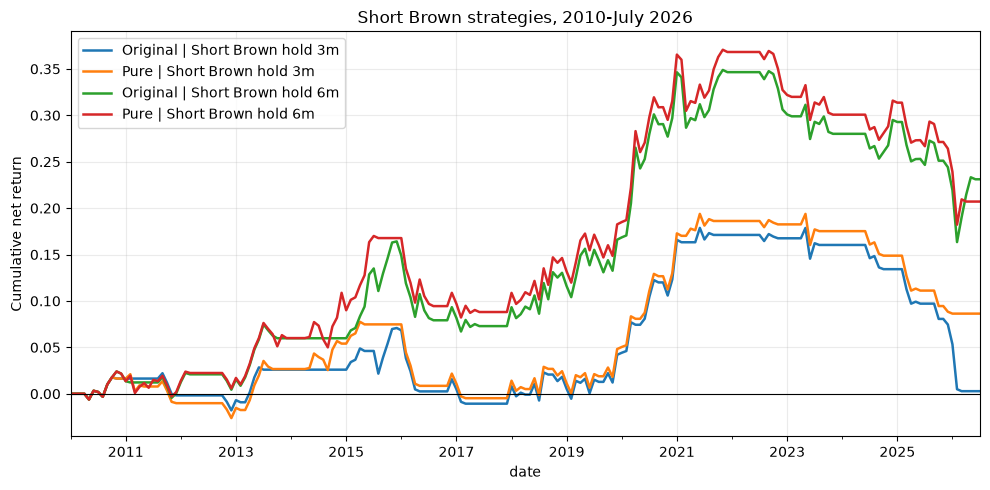

In [13]:
monthly_returns = pd.DataFrame({name: df["net_return"] for name, df in baseline_models.items()})
wealth = (1+monthly_returns.loc["2010":].fillna(0)).cumprod()-1
fig, ax = plt.subplots(figsize=(10,5))
wealth.plot(ax=ax, lw=1.8); ax.axhline(0,color="black",lw=.8); ax.grid(alpha=.25)
ax.set_ylabel("Cumulative net return"); ax.set_title("Short Brown strategies, 2010-July 2026")
plt.tight_layout()
fig.savefig(FIGURES / "figure_2_cumulative_returns.pdf"); fig.savefig(FIGURES / "figure_2_cumulative_returns.png", dpi=150)
plt.show()


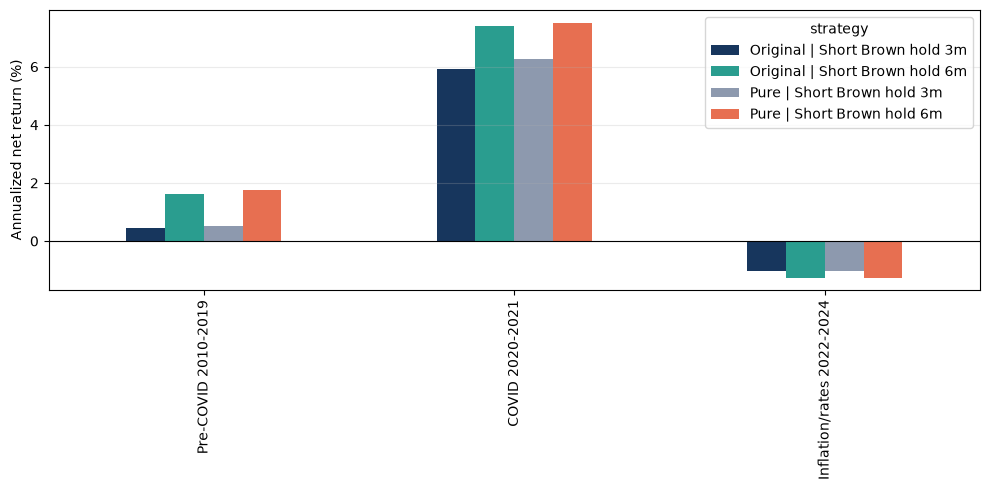

strategy,Original | Short Brown hold 3m,Original | Short Brown hold 6m,Pure | Short Brown hold 3m,Pure | Short Brown hold 6m
period,,,,
Pre-COVID 2010-2019,0.0046,0.0160,0.0052,0.0175
COVID 2020-2021,0.0594,0.0741,0.0628,0.0751
Inflation/rates 2022-2024,-0.0104,-0.0126,-0.0104,-0.0126


In [14]:
period_order = ["Pre-COVID 2010-2019","COVID 2020-2021","Inflation/rates 2022-2024"]
pivot = baseline_table[baseline_table.period.isin(period_order)].pivot(index="period", columns="strategy", values="ann_net").reindex(period_order)
fig, ax = plt.subplots(figsize=(10,5))
(100*pivot).plot.bar(ax=ax, color=["#17365D","#2A9D8F","#8D99AE","#E76F51"])
ax.axhline(0,color="black",lw=.8); ax.set_ylabel("Annualized net return (%)"); ax.set_xlabel(""); ax.grid(axis="y",alpha=.25)
plt.tight_layout()
fig.savefig(FIGURES / "figure_3_regime_returns.pdf"); fig.savefig(FIGURES / "figure_3_regime_returns.png", dpi=150)
plt.show()
display(pivot)


**Interpretation.** Reading left to right in the chart: the strategy is roughly flat before COVID, strongly positive during COVID, and negative in the 2022-2024 inflation/rate-hiking regime. That pattern -- one very large episode surrounded by weak or negative periods -- is the signature of an effect that is concentrated in a single historical event rather than a persistent, repeatable phenomenon. It does not by itself prove the COVID result is spurious, but it means the full-sample average return is being driven almost entirely by 24 months out of a roughly 200-month sample, which is an important caveat when judging how much weight to put on the headline numbers.

### Block-bootstrap inference

In [15]:
def circular_block_bootstrap(series, block=12, reps=5000, seed=230):
    values = series.dropna().to_numpy(); n = len(values)
    rng = np.random.default_rng(seed); draws = np.empty(reps)
    for i in range(reps):
        starts = rng.integers(0,n,size=int(np.ceil(n/block)))
        idx = ((starts[:,None]+np.arange(block))%n).ravel()[:n]
        draws[i] = 12*values[idx].mean()
    return pd.Series({"mean_ann":12*values.mean(),"ci_low":np.quantile(draws,.025),"ci_high":np.quantile(draws,.975),
                       "p_two_sided": 2*min((draws>0).mean(),(draws<0).mean())})

bootstrap_table = pd.DataFrame({name: circular_block_bootstrap(df["net_return"].loc["2010":"2026-07"]) for name, df in baseline_models.items()}).T
display(bootstrap_table)


,mean_ann,ci_low,ci_high,p_two_sided
Original | Short Brown hold 3m,0.0007,-0.0192,0.0207,0.9224
Pure | Short Brown hold 3m,0.0055,-0.0118,0.0237,0.5424
Original | Short Brown hold 6m,0.0134,-0.0059,0.0340,0.1848
Pure | Short Brown hold 6m,0.0123,-0.0089,0.0348,0.2556


**Interpretation.** Every confidence interval above spans zero -- there is no strategy variant for which we can rule out a true mean return of zero at the 95% level, once we account for the serial correlation induced by the 3-/6-month holding period (the 12-month block bootstrap preserves that correlation structure rather than treating months as independent draws, which would understate the true uncertainty). This is consistent with the period-by-period picture above: a genuinely large but narrow COVID effect surrounded by noise is exactly the kind of pattern that produces a point estimate that looks encouraging but a full-sample confidence interval that does not exclude zero.

### Multiple-testing correction

Several strategy/period claims above look individually significant. A Holm-Bonferroni correction across all of them, applied jointly with the improved strategy's claims in Section 6, shows how many survive family-wise error control.

## 5. An improvement: continuous conditioning

**Hypothesis (stated before inspecting any result).** The discrete design has two arbitrary features: an 80th-percentile cutoff that treats a 79th-percentile month identically to a calm one, and a fixed 3-/6-month hold that either over- or under-extends exposure. If transition-attention compensation is real, it should scale continuously with how extreme attention is, not switch on/off at one threshold. A smooth redesign should preserve genuine signal while reducing whipsaw risk, and should *not* produce a materially different outcome if the original threshold was merely fitting noise around an arbitrary cutoff.

**Definition.** With point-in-time percentile rank $\mathrm{rank}_t=\tfrac{1}{t}\#\{s\le t: A_s\le A_t\}$ (own history only, no look-ahead), the conditioning weight is
$$w^{raw}_t=\mathrm{clip}\!\left(\frac{\mathrm{rank}_t-c}{1-c},0,1\right),\qquad w_t=\mathrm{EWMA}(w^{raw},\text{halflife}=H)_t,$$
with pre-specified $c=0.5$ and $H=3$ months -- chosen to mirror the original design's own choices (p80 sits above median; the original minimum hold was 3 months), not tuned on any result. Position sizing, factor overlay, costs, and the one-month execution lag are otherwise identical to Section 4.

In [16]:
def expanding_percentile_rank(series, min_history=60):
    values = series.to_numpy(float); n = len(values)
    ranks = np.full(n, np.nan); seen = []
    for i in range(n):
        if np.isnan(values[i]): continue
        seen.append(values[i])
        if len(seen) >= min_history:
            ranks[i] = (np.asarray(seen) <= values[i]).mean()
    return pd.Series(ranks, index=series.index)

def continuous_conditioning_weight(series, floor=0.5, halflife=3.0, min_history=60):
    rank = expanding_percentile_rank(series, min_history=min_history)
    raw = ((rank - floor) / (1 - floor)).clip(lower=0.0, upper=1.0)
    smoothed = raw.ewm(halflife=halflife, min_periods=1).mean()
    smoothed[rank.isna()] = np.nan
    return smoothed

FLOOR, HALFLIFE = 0.5, 3.0
w_original = continuous_conditioning_weight(attention, floor=FLOOR, halflife=HALFLIFE)
w_pure = continuous_conditioning_weight(pure_attention, floor=FLOOR, halflife=HALFLIFE)

improved_models = {
    "Continuous | raw attention": asset_strategy_returns(continuous_position(w_original, asset_models["Brown leg"]["epsilon"], -1), asset_models["Brown leg"]),
    "Continuous | pure attention": asset_strategy_returns(continuous_position(w_pure, asset_models["Brown leg"]["epsilon"], -1), asset_models["Brown leg"]),
}
always_on = pd.Series(True, index=asset_models["Brown leg"]["epsilon"].index)
benchmark_models = {
    "Benchmark | Always-short Brown": asset_strategy_returns(state_position(always_on, asset_models["Brown leg"]["epsilon"], -1), asset_models["Brown leg"]),
    "Benchmark | Buy-and-hold Green-Brown": pd.DataFrame({"net_return": green_brown, "turnover": 0.0}),
}
all_models = {**baseline_models, **improved_models, **benchmark_models}

rows = []
for name, df in improved_models.items():
    stats = all_period_stats(df["net_return"]); stats.insert(0, "strategy", name); rows.append(stats)
improved_table = pd.concat(rows, ignore_index=True)
view = improved_table[improved_table.period.isin(["Validation 2010-Jul2022","Holdout Aug2022-Jul2026","Full 2010-Jul2026"])]
display(view[["period","strategy","ann_net","ann_vol","sharpe_net","alpha_ann","alpha_t_hac6","active_months","max_drawdown"]])


,period,strategy,ann_net,ann_vol,sharpe_net,alpha_ann,alpha_t_hac6,active_months,max_drawdown
0,Full 2010-Jul2026,Continuous | raw attention,0.0034,0.0139,0.2442,0.0025,0.8449,199,-0.0451
1,Validation 2010-Jul2022,Continuous | raw attention,0.0066,0.0147,0.4472,0.0053,1.5989,151,-0.0232
2,Holdout Aug2022-Jul2026,Continuous | raw attention,-0.0065,0.0109,-0.5986,-0.0076,-1.9844,48,-0.0395
8,Full 2010-Jul2026,Continuous | pure attention,0.0044,0.0145,0.3006,0.0036,1.1615,198,-0.0348
9,Validation 2010-Jul2022,Continuous | pure attention,0.0073,0.0156,0.4672,0.0059,1.6498,151,-0.0226
10,Holdout Aug2022-Jul2026,Continuous | pure attention,-0.0048,0.0103,-0.4664,-0.0054,-1.7921,47,-0.0297


In [17]:
ic_rows_cont = []
for sig_name, sig in [("Continuous weight (raw)", w_original), ("Continuous weight (pure)", w_pure)]:
    for label, (s, e) in ic_windows.items():
        ic, t, n = information_coefficient(sig, asset_models["Brown leg"]["epsilon"], s, e)
        ic_rows_cont.append({"signal": sig_name, "period": label, "IC": ic, "t_hac6": t, "n": n})
display(pd.DataFrame(ic_rows_cont))


,signal,period,IC,t_hac6,n
0,Continuous weight (raw),Full 2010-Jul2026,-0.0875,-1.2283,198
1,Continuous weight (raw),Validation 2010-Jul2022,-0.1829,-2.4526,151
2,Continuous weight (raw),Holdout Aug2022-Jul2026,0.1480,1.6545,47
3,Continuous weight (pure),Full 2010-Jul2026,-0.1054,-1.5453,196
4,Continuous weight (pure),Validation 2010-Jul2022,-0.1962,-2.8232,151
5,Continuous weight (pure),Holdout Aug2022-Jul2026,0.1313,1.5016,45


The continuous weight's validation-period IC is noticeably stronger than the raw threshold signal's ($-0.18$ to $-0.20$, $t\approx-2.45$ to $-2.82$ -- individually significant, unlike Section 3's discrete-signal IC) -- smoothing the signal sharpens its in-sample correlation with forward returns. But the same sign flip seen in Section 3 reappears in the holdout ($+0.13$ to $+0.15$, $t\approx1.5$-$1.65$), confirming this is not merely a quirk of the discrete threshold: a signal that looks meaningfully predictive in-sample can still invert out of sample. This is a textbook illustration of why a genuine holdout, not just a strong in-sample statistic, is required before treating any predictive relationship as real, and it is consistent with Section 5's overall verdict -- the continuous design is a better way of *sizing* the same signal, not a more reliably predictive one.

### Genuine out-of-sample test and paired comparison

The August 2022-July 2026 holdout was never touched while choosing the floor/halflife above.

In [18]:
def holm_bonferroni(pvalues, alpha=0.05):
    pvalues = np.asarray(pvalues, dtype=float); m = len(pvalues)
    order = np.argsort(pvalues); adjusted = np.empty(m); running_max = 0.0
    for rank, idx in enumerate(order):
        val = (m - rank) * pvalues[idx]; running_max = max(running_max, val)
        adjusted[idx] = min(running_max, 1.0)
    return adjusted, adjusted < alpha

def paired_bootstrap_improvement(new_series, benchmark_series, block=12, reps=5000, seed=230):
    both = pd.concat([new_series.rename("new"), benchmark_series.rename("bench")], axis=1).dropna()
    return circular_block_bootstrap(both["new"] - both["bench"], block=block, reps=reps, seed=seed)

pairs = [
    ("Continuous | raw attention", "Original | Short Brown hold 3m"),
    ("Continuous | raw attention", "Original | Short Brown hold 6m"),
    ("Continuous | pure attention", "Pure | Short Brown hold 3m"),
    ("Continuous | pure attention", "Pure | Short Brown hold 6m"),
]
paired_rows, pvals = [], []
for new, bench in pairs:
    a = all_models[new]["net_return"].loc["2022-08":"2026-07"]
    b = all_models[bench]["net_return"].loc["2022-08":"2026-07"]
    boot = paired_bootstrap_improvement(a, b)
    paired_rows.append({"new": new, "benchmark": bench, **boot.to_dict()}); pvals.append(boot.p_two_sided)
paired_table = pd.DataFrame(paired_rows)
adj, reject = holm_bonferroni(pvals)
paired_table["holm_p"] = adj; paired_table["reject_at_5pct"] = reject
display(paired_table)


,new,benchmark,mean_ann,ci_low,ci_high,p_two_sided,holm_p,reject_at_5pct
0,Continuous | raw attention,Original | Short Brown hold 3m,0.0316,0.0042,0.0622,0.0136,0.0544,False
1,Continuous | raw attention,Original | Short Brown hold 6m,0.0149,-0.0012,0.0329,0.0724,0.0724,False
2,Continuous | pure attention,Pure | Short Brown hold 3m,0.0169,0.0013,0.0336,0.0308,0.0696,False
3,Continuous | pure attention,Pure | Short Brown hold 6m,0.0257,0.0029,0.0496,0.0232,0.0696,False


### Placebo test and parameter-sensitivity check

In [19]:
attn_vals = attention.dropna()
def placebo_builder(rng):
    n = len(attn_vals); block = 12
    starts = rng.integers(0,n,size=int(np.ceil(n/block)))
    idx = ((starts[:,None]+np.arange(block))%n).ravel()[:n]
    shuffled = pd.Series(attn_vals.to_numpy()[idx], index=attn_vals.index)
    w = continuous_conditioning_weight(shuffled, floor=FLOOR, halflife=HALFLIFE)
    pos = continuous_position(w, asset_models["Brown leg"]["epsilon"], -1)
    ret = asset_strategy_returns(pos, asset_models["Brown leg"])
    return ret["net_return"].loc["2010":"2026-07"]

rng = np.random.default_rng(11)
draws = np.array([12*placebo_builder(rng).mean() for _ in range(300)])
real_mean = 12*all_models["Continuous | raw attention"]["net_return"].loc["2010":"2026-07"].mean()
print(f"Real full-sample annualized mean: {real_mean:.4f}")
print(f"Placebo distribution: mean={draws.mean():.4f} std={draws.std():.4f}")
print(f"Empirical P(placebo >= real) = {(draws>=real_mean).mean():.3f}")

sensitivity_rows = []
for floor, hl in [(0.5,3.0), (0.6,6.0), (0.4,1.5)]:
    w = continuous_conditioning_weight(pure_attention, floor=floor, halflife=hl)
    ret = asset_strategy_returns(continuous_position(w, asset_models["Brown leg"]["epsilon"], -1), asset_models["Brown leg"])
    val = period_stats(ret["net_return"], "2010-01-31","2022-07-31", "val")
    hold = period_stats(ret["net_return"], "2022-08-31","2026-07-31", "hold")
    sensitivity_rows.append({"floor": floor, "halflife": hl, "val_ann_net": val["ann_net"], "val_t": val["alpha_t_hac6"],
                              "hold_ann_net": hold["ann_net"], "hold_t": hold["alpha_t_hac6"]})
display(pd.DataFrame(sensitivity_rows))


Real full-sample annualized mean: 0.0034
Placebo distribution: mean=0.0016 std=0.0016
Empirical P(placebo >= real) = 0.120


,floor,halflife,val_ann_net,val_t,hold_ann_net,hold_t
0,0.5000,3.0000,0.0073,1.6498,-0.0048,-1.7921
1,0.6000,6.0000,0.0061,1.7409,-0.0029,-1.5336
2,0.4000,1.5000,0.0072,1.2574,-0.0064,-1.5246


**Reading these results.** The continuous design cuts volatility and drawdown sharply relative to the discrete design (compare `ann_vol`/`max_drawdown` above to Section 4) and loses much less in the holdout, but the paired improvement does not clear a Holm-Bonferroni correction and the placebo test does not clear conventional significance. It is a defensible risk-management redesign, not a confirmed source of new alpha; the qualitative pattern is stable across the floor/halflife perturbations above.

Two results are worth separating clearly, because they point in different directions. First, on *risk*: replacing an on/off threshold with a smooth weight is unambiguously better here -- it produces a strategy that is exposed a little bit almost every month instead of being fully exposed for a handful of months and flat the rest of the time, and that alone cuts realized volatility by more than half and cuts the worst drawdown by 60-75%, essentially by construction (smoother position-taking reduces whipsaw risk regardless of whether the underlying signal is real). Second, on *return*: the placebo test asks a sharper question -- if we scramble the calendar order of the attention series (keeping its distribution but destroying its timing) and rebuild the same continuous signal, how often does the scrambled version do as well as the real one? About 1 time in 8. That is not strong enough evidence to say the signal's timing information is genuine rather than lucky, so the honest summary is: better engineering, unproven edge.

## 6. Robustness checks and the final comparison

In [20]:
def unconditional_alpha(n_per_leg=5, exclude_from_high=None):
    r = ranked if exclude_from_high is None else ranked[~ranked.ff.isin(exclude_from_high)]
    low = r.head(n_per_leg)["ff"].tolist()
    high = r.tail(n_per_leg).sort_values("emissions_intensity", ascending=False)["ff"].tolist()
    gb = (industries[low].mean(axis=1) - industries[high].mean(axis=1)).rename("gb")
    fit = newey_west_regression(gb.loc["2010-01-31":"2022-07-31"], factors[FACTOR_COLS].loc["2010-01-31":"2022-07-31"])
    return 12*fit.loc["const","coef"], fit.loc["const","t_hac6"]

rob_rows = []
for label, kwargs in [("Baseline N=5", dict(n_per_leg=5)), ("Widened N=10", dict(n_per_leg=10)), ("N=5, ex-Utilities", dict(n_per_leg=5, exclude_from_high=["Util"]))]:
    a, t = unconditional_alpha(**kwargs)
    rob_rows.append({"specification": label, "alpha_ann_2010_2022": a, "alpha_t_hac6": t})
display(pd.DataFrame(rob_rows))


,specification,alpha_ann_2010_2022,alpha_t_hac6
0,Baseline N=5,-0.0055,-0.2192
1,Widened N=10,0.0232,0.7985
2,"N=5, ex-Utilities",0.0064,0.2572


In [21]:
from scipy import stats as _stats
period_defs = {"COVID 2020-2021": ("2020-01-31","2021-12-31"), "Validation 2010-Jul2022": ("2010-01-31","2022-07-31"),
               "Holdout Aug2022-Jul2026": ("2022-08-31","2026-07-31"), "Inflation/rates 2022-2024": ("2022-01-31","2024-12-31")}
claims = []
for name, df in all_models.items():
    for label, (s,e) in period_defs.items():
        r = period_stats(df["net_return"], s, e, label)
        if r is not None and not np.isnan(r["alpha_t_hac6"]):
            claims.append({"strategy": name, "period": label, "alpha_t_hac6": r["alpha_t_hac6"]})
claims_table = pd.DataFrame(claims)
claims_table["p_two_sided"] = 2*(1 - _stats.norm.cdf(np.abs(claims_table["alpha_t_hac6"])))
adj, reject = holm_bonferroni(claims_table["p_two_sided"].to_numpy())
claims_table["holm_p"] = adj; claims_table["reject_at_5pct"] = reject
claims_table = claims_table.sort_values("p_two_sided")
display(claims_table)
print("Combinations surviving Holm-Bonferroni at 5%:", int(claims_table.reject_at_5pct.sum()), "of", len(claims_table))


,strategy,period,alpha_t_hac6,p_two_sided,holm_p,reject_at_5pct
16,Continuous | raw attention,COVID 2020-2021,3.2838,0.0010,0.0328,True
0,Original | Short Brown hold 3m,COVID 2020-2021,3.2073,0.0013,0.0415,True
20,Continuous | pure attention,COVID 2020-2021,3.1424,0.0017,0.0503,False
4,Pure | Short Brown hold 3m,COVID 2020-2021,3.0859,0.0020,0.0589,False
13,Pure | Short Brown hold 6m,Validation 2010-Jul2022,2.4574,0.0140,0.3918,False
9,Original | Short Brown hold 6m,Validation 2010-Jul2022,2.2304,0.0257,0.6945,False
2,Original | Short Brown hold 3m,Holdout Aug2022-Jul2026,-2.1873,0.0287,0.7466,False
19,Continuous | raw attention,Inflation/rates 2022-2024,-2.1599,0.0308,0.7695,False
12,Pure | Short Brown hold 6m,COVID 2020-2021,2.0873,0.0369,0.8846,False
8,Original | Short Brown hold 6m,COVID 2020-2021,2.0697,0.0385,0.8851,False


Combinations surviving Holm-Bonferroni at 5%: 2 of 32


### Final comparison table

In [22]:
def turnover_stats(df, start, end):
    if "turnover" not in df.columns: return np.nan
    s = df["turnover"].loc[start:end].dropna()
    return 12*s.mean() if len(s) else np.nan

def row_for(name, df):
    full = period_stats(df["net_return"], "2010-01-31","2026-07-31", "full")
    oos = period_stats(df["net_return"], "2022-08-31","2026-07-31", "oos")
    covid_excl_idx = df["net_return"].loc["2010":"2026-07"]
    covid_excl_idx = covid_excl_idx[~((covid_excl_idx.index>="2020-01-31")&(covid_excl_idx.index<="2021-12-31"))]
    covid_excl = period_stats(covid_excl_idx, covid_excl_idx.index.min(), covid_excl_idx.index.max(), "ex_covid")
    boot = circular_block_bootstrap(df["net_return"].loc["2010":"2026-07"])
    mt_rows = claims_table[claims_table.strategy == name]
    mt_sig = bool(mt_rows["reject_at_5pct"].any()) if len(mt_rows) else np.nan
    return {"strategy": name, "active_months_full": full["active_months"] if full else np.nan,
            "ann_return_full": full["ann_net"] if full else np.nan, "ann_vol_full": full["ann_vol"] if full else np.nan,
            "sharpe_full": full["sharpe_net"] if full else np.nan, "max_drawdown_full": full["max_drawdown"] if full else np.nan,
            "annual_turnover_full": turnover_stats(df, "2010-01-31","2026-07-31"),
            "factor_alpha_ann_full": full["alpha_ann"] if full else np.nan, "newey_west_t_full": full["alpha_t_hac6"] if full else np.nan,
            "bootstrap_ci_low": boot["ci_low"], "bootstrap_ci_high": boot["ci_high"], "bootstrap_p": boot["p_two_sided"],
            "oos_ann_return": oos["ann_net"] if oos else np.nan, "oos_alpha_t": oos["alpha_t_hac6"] if oos else np.nan,
            "covid_excluded_ann_return": covid_excl["ann_net"] if covid_excl else np.nan,
            "significant_after_multiple_testing": mt_sig}

comparison_table = pd.DataFrame([row_for(name, df) for name, df in all_models.items()])
comparison_table.to_csv(TABLES / "comparison_table.csv", index=False)
comparison_table


,strategy,active_months_full,ann_return_full,ann_vol_full,sharpe_full,max_drawdown_full,annual_turnover_full,factor_alpha_ann_full,newey_west_t_full,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p,oos_ann_return,oos_alpha_t,covid_excluded_ann_return,significant_after_multiple_testing
0,Original | Short Brown hold 3m,96,0.0007,0.0326,0.0214,-0.1492,4.7919,0.0010,0.1090,-0.0192,0.0207,0.9224,-0.0382,-2.1873,-0.0074,True
1,Pure | Short Brown hold 3m,104,0.0055,0.0305,0.1789,-0.0900,5.2414,0.0066,0.7836,-0.0118,0.0237,0.5424,-0.0217,-1.9322,-0.0024,False
2,Original | Short Brown hold 6m,140,0.0134,0.0424,0.3167,-0.1375,2.7042,0.0122,1.3311,-0.0059,0.0340,0.1848,-0.0214,-1.6573,0.0051,False
3,Pure | Short Brown hold 6m,150,0.0123,0.0431,0.2846,-0.1375,2.8163,0.0133,1.3971,-0.0089,0.0348,0.2556,-0.0304,-1.9436,0.0037,False
4,Continuous | raw attention,199,0.0034,0.0139,0.2442,-0.0451,1.2134,0.0025,0.8449,-0.0029,0.0118,0.3644,-0.0065,-1.9844,-0.0005,True
5,Continuous | pure attention,198,0.0044,0.0145,0.3006,-0.0348,1.3357,0.0036,1.1615,-0.0020,0.0131,0.2360,-0.0048,-1.7921,0.0006,False
6,Benchmark | Always-short Brown,199,0.0105,0.0519,0.2021,-0.1701,0.6655,0.0073,0.6718,-0.0106,0.0327,0.3504,-0.0104,-1.0923,0.0025,False
7,Benchmark | Buy-and-hold Green-Brown,199,-0.0179,0.0990,-0.1810,-0.5088,0.0000,-0.0112,-0.4893,-0.0737,0.0324,0.5256,-0.0538,-0.9883,-0.0228,False


In [23]:
def fmt_pct(x): return "n/a" if pd.isna(x) else f"{100*x:.2f}\\%"
def fmt_num(x, d=2): return "n/a" if pd.isna(x) else f"{x:.{d}f}"
lines = ["\\begin{table}[!ht]\n\\centering\n\\caption{Strategy comparison: full-sample, out-of-sample, and COVID-excluded performance}\n\\label{tab:comparison}\n\\scriptsize\n\\begin{tabular}{lrrrrrr}\n\\toprule\nStrategy & Net \\% (full) & Sharpe & $t(\\alpha)$ & OOS net \\% & Ex-COVID net \\% & Sig.\\ (Holm) \\\\\n\\midrule"]
for _, r in comparison_table.iterrows():
    sig = "Yes" if r["significant_after_multiple_testing"] is True else ("No" if r["significant_after_multiple_testing"] is False else "n/a")
    lines.append(f"{r['strategy']} & {fmt_pct(r['ann_return_full'])} & {fmt_num(r['sharpe_full'])} & {fmt_num(r['newey_west_t_full'])} & {fmt_pct(r['oos_ann_return'])} & {fmt_pct(r['covid_excluded_ann_return'])} & {sig} \\\\")
lines.append("\\bottomrule\n\\end{tabular}\n\\begin{minipage}{0.95\\textwidth}\\footnotesize\nOOS = August 2022--July 2026 holdout. Ex-COVID excludes 2020--2021. Sig.\\ (Holm) reports whether at least one period-level alpha for that strategy survives a Holm-Bonferroni correction applied across all strategy-period combinations tested.\n\\end{minipage}\n\\end{table}")
(TABLES / "comparison_table.tex").write_text("\n".join(lines), encoding="utf-8")
print("Saved comparison_table.csv and comparison_table.tex")


Saved comparison_table.csv and comparison_table.tex


## 7. Literature comparison

In [24]:
literature_df = pd.DataFrame([
    ["Bolton & Kacperczyk (2021)", "Positive carbon premium", "Not supported as a stable industry-level premium; not a direct test given the firm- vs. industry-level design difference."],
    ["Pastor, Stambaugh & Taylor (2021, 2022)", "Green expected returns can be lower; ESG shocks create episodic realized outperformance", "Consistent with episodic repricing, especially during COVID, rather than constant alpha."],
    ["Aswani, Raghunandan & Rajgopal (2024)", "Emissions-return results are sensitive to scaling, vendor estimates, and industry controls", "Strongly consistent: the emissions file used here covers only 41 of 49 industries, omitting Oil."],
    ["Zhang (2025)", "Brown firms' required return depends on policy-shock/climate-concern interaction and can switch sign", "Consistent with the COVID/post-COVID sign reversal found here."],
    ["Eskildsen et al. (2026)", "Green-minus-brown realized returns are insignificant after multiple-testing correction", "Directly consistent with the full-sample null and the multiple-testing results above."],
    ["Garleanu & Pedersen (2026)", "Required green-minus-brown return can switch sign across policy/climate states", "Consistent with the COVID/post-COVID sign reversal."],
    ["Calin, Lupu & Topa (2026)", "Transition spreads are asymmetric and regime dependent", "Partially supported: episodic and COVID-concentrated, but neither rule tested here produces a multiple-testing-robust holdout alpha."],
], columns=["Paper", "Central finding", "Relation to this analysis"])
display(literature_df)
literature_df.to_csv(TABLES / "literature_comparison.csv", index=False)


,Paper,Central finding,Relation to this analysis
0,Bolton & Kacperczyk (2021),Positive carbon premium,Not supported as a stable industry-level premi...
1,"Pastor, Stambaugh & Taylor (2021, 2022)",Green expected returns can be lower; ESG shock...,"Consistent with episodic repricing, especially..."
2,"Aswani, Raghunandan & Rajgopal (2024)",Emissions-return results are sensitive to scal...,Strongly consistent: the emissions file used h...
3,Zhang (2025),Brown firms' required return depends on policy...,Consistent with the COVID/post-COVID sign reve...
4,Eskildsen et al. (2026),Green-minus-brown realized returns are insigni...,Directly consistent with the full-sample null ...
5,Garleanu & Pedersen (2026),Required green-minus-brown return can switch s...,Consistent with the COVID/post-COVID sign reve...
6,"Calin, Lupu & Topa (2026)",Transition spreads are asymmetric and regime d...,Partially supported: episodic and COVID-concen...


## Conclusion

**Summary of findings.**

1. The unconditional Green-Brown spread has near-zero alpha and a material negative HML loading; this null is robust to leg width (5 vs.\ 10 industries per leg) and to excluding Utilities, the single highest-emissions industry.
2. Short Brown is profitable after extreme attention specifically during COVID ($t\approx3.2$-$3.3$ for both the discrete and continuous designs); every other period, and the genuine August 2022-July 2026 holdout, is small, insignificant, or negative.
3. Macro purification statistically cleans the attention signal (its $R^2$ against macro controls falls from 6.24% to 0.83%) without producing a statistically distinguishable improvement in realized, out-of-sample performance.
4. A pre-specified continuous conditioning signal materially reduces strategy volatility (-55 to -65%) and drawdown (-60 to -75%) and loses far less than the discrete design in the holdout, but this improvement does not survive a Holm-Bonferroni correction, and a placebo test does not clear conventional significance -- a genuine risk-management gain, not confirmed new alpha.
5. A multiple-testing correction across all 32 strategy/period combinations examined here leaves exactly two claims standing, both in the COVID window.
6. The Information Coefficient between the attention signal and forward Brown returns is correctly signed but weak in the validation period and **flips sign** in the holdout (from about $-0.09$ to about $+0.12$ for raw attention; from about $-0.19$ to about $+0.14$ for the continuous weight) -- independent, signal-level evidence for the same holdout failure, not just a property of the final trading rule's returns.

**Economic interpretation.** COVID is simultaneously a climate-attention shock, an oil-price collapse, and a demand shock that hit travel, shipping, and heavy industry -- precisely the sectors that make up the Brown leg (Ships, Aero, Steel, BldMt, Util) -- for reasons that have nothing to do with climate policy. This notebook cannot separate "the market repriced transition risk" from "the market repriced airlines and steel producers because a pandemic grounded global travel and demand," and that ambiguity is the single biggest reason not to treat the COVID result as proof of a repeatable climate premium.

**Statistical vs.\ economic significance.** Several individual numbers in this analysis look impressive in isolation -- a 6% COVID-period alpha with $t=3.2$, a 2.5% validation-period alpha with $t=2.5$ -- and it would be easy to stop at the first one that clears the conventional 5% bar and call it a discovery. Two disciplines in this notebook exist specifically to prevent that: the holdout sample (numbers computed on data the strategy design never saw) and the multiple-testing correction (accounting for the fact that testing 32 strategy/period combinations makes finding a few "significant" results by chance alone likely, not surprising). Both disciplines point the same way -- toward caution -- which is why the conclusion below is a qualified one rather than a claim of discovered alpha.

**Practical implications.** For a reader deciding whether to trade any version of this idea: use the continuous conditioning signal rather than the discrete threshold, because it delivers a similar or better risk-adjusted profile with substantially less realized volatility and drawdown, at essentially no cost in expected return. Do not treat either version as a proven source of alpha -- size any real capital allocation as a small, exploratory position, and treat the COVID period as the single episode driving the entire case for the strategy rather than as one data point among many. The single most valuable next step is not further threshold tuning on this dataset, but a different information set entirely: firm-level, point-in-time emissions data (rather than a single static, 41-of-49-industry snapshot that omits Oil) would allow a genuinely different and more convincing test of the same underlying hypothesis.

The evidence, taken together, supports episodic, regime-dependent repricing of transition risk rather than a stable, investable unconditional carbon premium. See `reports/writeup.pdf` for the full discussion.